In [1]:
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import polars as pl

import parcels

from src.saws_functions import release_points_from_SaWS_images  # noqa: E402

/var/folders/1n/500ln6w97859_nqq86vwpl000000gr/T/ipykernel_29424/794202035.py:8: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
coords = release_points_from_SaWS_images(datetime(2024, 8, 1), stride=8)

In [3]:
df = parcels.read_particlefile("../Simulations/Simulation_Satellite_kN_0.001.parquet")

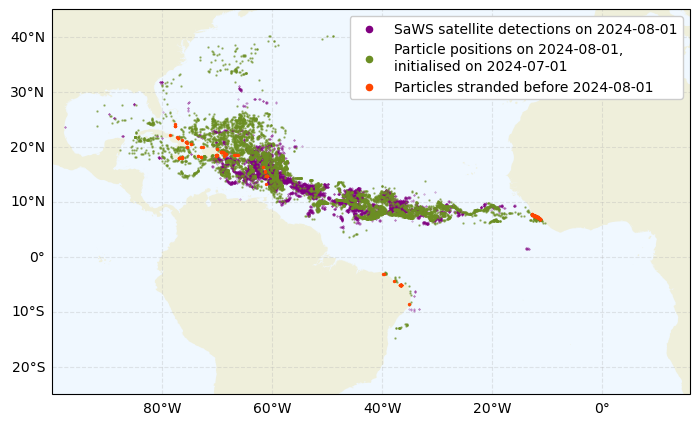

In [4]:
fig = plt.figure(figsize = (10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor('aliceblue')
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

first_time = df.select(pl.col("time").min()).item()
last_time = df.select(pl.col("time").max()).item()
last_locations = df.filter(pl.col("time") == last_time)
stranded = df.filter(pl.col("stranded"))

satplot = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=0.1,
    alpha=0.6,
    c='purple',
    label='SaWS satellite detections on 2024-08-01',
    zorder=6,
)

endplot = ax.scatter(
    last_locations["lon"],
    last_locations["lat"],
    s=0.5,
    alpha=0.6,
    color='olivedrab',
    label=f'Particle positions on {last_time.strftime("%Y-%m-%d")},\ninitialised on {first_time.strftime("%Y-%m-%d")}',
    zorder=7,
)

stranded_plot = ax.scatter(
    stranded["lon"],
    stranded["lat"],
    s=2,
    color='orangered',
    label=f'Particles stranded before {last_time.strftime("%Y-%m-%d")}',
    zorder=10,
    )

ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_extent([-100, 16, -25, 45], crs=ccrs.PlateCarree())

leg = ax.legend(framealpha=1)
leg.set_zorder(11)
for handle in leg.legend_handles:
    handle.set_sizes([20])
    handle.set_alpha(1.0)

fig.savefig('Figures/Figure2.png', bbox_inches='tight', dpi=300)

plt.show()

In [5]:
print(f"Percentage of particles that stranded: {stranded.shape[0] / last_locations.shape[0] * 100:.2f}%")

Percentage of particles that stranded: 2.11%
